In [1]:
import os, sys, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Resolve project root (notebooks/ is 1 level below project root)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DATASET_PATH, FIGURES_M1_DIR, FIGURES_INTERACTIVE_DIR

sns.set_theme(style="whitegrid")
FIGURES_M1_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_INTERACTIVE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = FIGURES_M1_DIR


## 1. Load and structure

In [2]:
# put the csv in the same folder as this notebook
# (on Colab: upload it from the Files panel on the left)
DATA_PATH = RAW_DATASET_PATH
EXPECTED_SHA = "de94302b867c9debedfd45c431306623fdfc038f5ed8ca17736339b4460a6674"   # dataset verified in M1-T01

sha = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print("SHA256:", sha)
print("-> matches the dataset verified in M1-T01" if sha == EXPECTED_SHA
      else "-> WARNING: this file is NOT the one verified in M1-T01. Check it before trusting the results.")

df = pd.read_csv(DATA_PATH, parse_dates=["transaction_date", "expiration_date"])

print(df.shape)
assert df.shape == (100_000, 42), "Unexpected shape"

SHA256: de94302b867c9debedfd45c431306623fdfc038f5ed8ca17736339b4460a6674
-> matches the dataset verified in M1-T01


(100000, 42)


In [3]:
# In some copies of the CSV the header of the day-of-week column is blank and pandas calls it "Unnamed: 17".
# Rename it only after proving it really is the weekday of transaction_date.
if "Unnamed: 17" in df.columns:
    same = (df["Unnamed: 17"] == df["transaction_date"].dt.dayofweek).mean()
    print("'Unnamed: 17' equals the weekday of transaction_date in", round(same * 100, 2), "% of rows")
    assert same == 1.0, "Unnamed: 17 is not day_of_week - investigate before renaming"
    df = df.rename(columns={"Unnamed: 17": "day_of_week"})
assert "day_of_week" in df.columns and not any(c.startswith("Unnamed") for c in df.columns)

In [4]:
df.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   record_id                   100000 non-null  int64         
 1   product_id                  100000 non-null  object        
 2   product_name                100000 non-null  object        
 3   category                    100000 non-null  object        
 4   store_id                    100000 non-null  object        
 5   region                      100000 non-null  object        
 6   supplier_id                 100000 non-null  object        
 7   transaction_date            100000 non-null  datetime64[ns]
 8   expiration_date             100000 non-null  datetime64[ns]
 9   shelf_life_days             100000 non-null  int64         
 10  days_remaining_at_purchase  100000 non-null  int64         
 11  storage_temp                100000 non-n

In [6]:
df.nunique().sort_values()

is_promoted                        2
was_spoiled                        2
is_weekend                         2
markdown_applied                   2
quality_grade                      3
region                             5
supplier_score                     5
packaging_score                    6
handling_score                     7
day_of_week                        7
spoilage_sensitivity               9
category                          10
temp_abuse_events                 11
month                             12
supplier_id                       20
demand_variability                41
store_id                          50
product_name                      63
discount_pct                      67
temp_deviation                    84
spoilage_risk                    377
storage_temp                     476
initial_quantity                 491
units_sold                       501
units_wasted                     501
distribution_hours               681
days_until_expiry                712
d

In [7]:
# split the columns into groups
id_cols = [c for c in df.columns if c.endswith("_id")]
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c not in id_cols]      # ids are labels, not real numbers
cat_cols = df.select_dtypes(exclude=["number", "datetime"]).columns.tolist()

print("id columns:", id_cols)
print("numeric columns:", len(num_cols))
print("text columns:", cat_cols)

id columns: ['record_id', 'product_id', 'store_id', 'supplier_id']
numeric columns: 32
text columns: ['product_id', 'product_name', 'category', 'store_id', 'region', 'supplier_id', 'quality_grade']


In [8]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
shelf_life_days,100000.0,67.17,140.55,1.00,5.00,9.00,24.00,730.00
days_remaining_at_purchase,100000.0,56.11,118.16,0.00,4.00,8.00,20.00,723.00
storage_temp,100000.0,3.13,9.50,-27.70,1.10,4.00,6.60,27.70
temp_deviation,100000.0,1.60,1.21,0.00,0.60,1.40,2.30,9.00
base_price,100000.0,36.41,87.42,1.00,6.27,10.22,17.01,499.98
cost_price,100000.0,20.06,48.89,0.41,3.36,5.58,9.50,346.61
initial_quantity,100000.0,254.85,141.69,10.00,132.00,255.00,377.00,500.00
spoilage_sensitivity,100000.0,0.69,0.22,0.30,0.50,0.75,0.90,0.95
day_of_week,100000.0,3.00,2.00,0.00,1.00,3.00,5.00,6.00
is_weekend,100000.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00


In [9]:
print("rows:", len(df))
print("columns:", df.shape[1])
print("categories:", df["category"].nunique())
print("stores:", df["store_id"].nunique())
print("regions:", df["region"].nunique())
print("suppliers:", df["supplier_id"].nunique())
print("dates from", df["transaction_date"].min().date(), "to", df["transaction_date"].max().date())

rows: 100000
columns: 42
categories: 10
stores: 50
regions: 5
suppliers: 20
dates from 2023-01-01 to 2024-12-31


## 2. Data quality

Missing values, duplicates, impossible values, and how the date columns are defined.

In [10]:
missing = df.isnull().sum()
print("total missing values:", int(missing.sum()))
print("columns with missing values:", missing[missing > 0].to_dict() or "none")

# hidden gaps: blank text cells
blank_text = {c: int((df[c].astype(str).str.strip() == "").sum()) for c in cat_cols}
print("blank text cells:", {k: v for k, v in blank_text.items() if v} or "none")

assert missing.sum() == 0

total missing values: 0
columns with missing values: none


blank text cells:

 none


In [11]:
# record_id is unique by construction, so duplicates must be searched WITHOUT it
print("record_id unique:", df["record_id"].is_unique)
n_dup = int(df.drop(columns="record_id").duplicated().sum())
print("duplicate rows (ignoring record_id):", n_dup)
assert df["record_id"].is_unique and n_dup == 0

record_id unique: True
duplicate rows (ignoring record_id): 0


In [12]:
# each line counts the rows where something looks wrong
# note: discount_pct is a FRACTION (0.25 = 25%), waste_pct is a PERCENT (25.0 = 25%)
checks = {
    "expiry date before transaction date": (df["expiration_date"] < df["transaction_date"]).sum(),
    "negative units_sold": (df["units_sold"] < 0).sum(),
    "negative units_wasted": (df["units_wasted"] < 0).sum(),
    "discount_pct outside 0-1": ((df["discount_pct"] < 0) | (df["discount_pct"] > 1)).sum(),
    "waste_pct outside 0-100": ((df["waste_pct"] < 0) | (df["waste_pct"] > 100)).sum(),
    "was_spoiled is not 0 or 1": (~df["was_spoiled"].isin([0, 1])).sum(),
    "selling_price higher than base_price": (df["selling_price"] > df["base_price"]).sum(),
    "units_sold + units_wasted more than initial_quantity":
        ((df["units_sold"] + df["units_wasted"]) > df["initial_quantity"]).sum(),
}
result = pd.Series(checks, name="rows")
assert (result == 0).all(), result[result != 0]
result

expiry date before transaction date                     0
negative units_sold                                     0
negative units_wasted                                   0
discount_pct outside 0-1                                0
waste_pct outside 0-100                                 0
was_spoiled is not 0 or 1                               0
selling_price higher than base_price                    0
units_sold + units_wasted more than initial_quantity    0
Name: rows, dtype: int64

In [13]:
#show how the columns are defined
# do days_until_expiry / days_remaining_at_purchase match the gap between the two dates?
gap = (df["expiration_date"] - df["transaction_date"]).dt.days
print("days_until_expiry differs from the date gap in", (gap != df["days_until_expiry"]).sum(), "rows")
print("days_remaining_at_purchase differs from the date gap in", (gap != df["days_remaining_at_purchase"]).sum(), "rows")

days_until_expiry differs from the date gap in 74191 rows
days_remaining_at_purchase differs from the date gap in 0 rows


In [14]:
diff = df["days_remaining_at_purchase"] - df["days_until_expiry"]

print(diff.describe())
print((diff < 0).sum(), "rows where days_until_expiry is BIGGER than days_remaining_at_purchase")
print(diff.value_counts().head(10))

df[["transaction_date", "expiration_date", "shelf_life_days",
    "days_remaining_at_purchase", "days_until_expiry"]].head(10)

count    100000.000000
mean          1.439750
std           1.097389
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           3.000000
dtype: float64
0 rows where days_until_expiry is BIGGER than days_remaining_at_purchase
1    26492
0    25809
2    25614
3    22085
Name: count, dtype: int64


,transaction_date,expiration_date,shelf_life_days,days_remaining_at_purchase,days_until_expiry
0,2024-09-25,2024-09-29,4,4,2
1,2023-04-14,2023-04-21,9,7,4
2,2024-10-25,2024-10-27,2,2,0
3,2023-11-29,2024-02-17,87,80,79
4,2023-08-06,2023-08-09,4,3,3
5,2024-08-21,2025-07-06,468,319,317
6,2023-02-18,2023-02-27,10,9,8
7,2024-04-24,2025-02-16,330,298,297
8,2024-10-18,2025-10-17,378,364,364
9,2023-07-02,2023-07-08,6,6,5


In [15]:
# days_until_expiry is 0-3 days lower than days_remaining_at_purchase: is that gap related to the distribution time?
lag = df["days_remaining_at_purchase"] - df["days_until_expiry"]
pd.crosstab(lag, (df["distribution_hours"] // 24).astype(int),
            rownames=["days lost (remaining - until_expiry)"], colnames=["distribution_hours // 24"])

distribution_hours // 24,0,1,2,3
days lost (remaining - until_expiry),,,,
0,7515,9261,9013,20
1,7902,9327,9243,20
2,7467,8904,9229,14
3,6477,7812,7779,17


**Finding - date columns.**
`days_remaining_at_purchase` equals `expiration_date - transaction_date` in all 100,000 rows. `days_until_expiry` is 0 to 3 days lower (mean 1.4 days) and never higher. The table above shows that this gap is **not** explained by `distribution_hours`: each gap size (0, 1, 2 or 3 days) is spread almost evenly over the 0-day, 1-day and 2-day distribution bands (the 3-day band, exactly 72 hours, has only about 70 rows). The source of the 0-3 day difference is therefore unknown and is noted as a data limitation.
For modelling, `days_until_expiry` is used as the time left on the shelf (with the ratio `days_until_expiry / shelf_life_days`), and `shelf_life_days - days_remaining_at_purchase` is the age of the batch when it was bought.

In [16]:
for col in ["category", "region", "quality_grade"]:
    print(col, "->", sorted(df[col].astype(str).unique()))

category -> ['Bakery', 'Beverages', 'Dairy', 'Deli', 'Frozen_Meals', 'Meat', 'Pharmaceuticals', 'Produce', 'Ready_to_Eat', 'Seafood']
region -> ['Midwest', 'Northeast', 'Southeast', 'Southwest', 'West']
quality_grade -> ['A', 'B', 'C']


## 3. Distributions and target balance

was_spoiled
0    80558
1    19442
Name: count, dtype: int64

was_spoiled
0    0.806
1    0.194
Name: proportion, dtype: float64


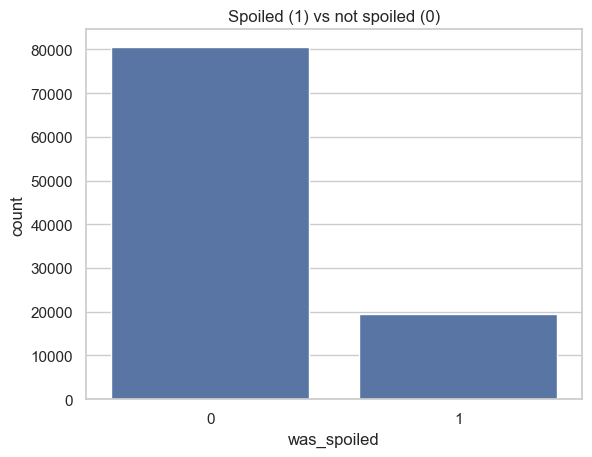

In [17]:
#how many batches spoiled 
print(df["was_spoiled"].value_counts())
print()
print(df["was_spoiled"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="was_spoiled")
plt.title("Spoiled (1) vs not spoiled (0)")
plt.savefig(FIG_DIR / "01_target_balance.png", dpi=150, bbox_inches="tight")
plt.show()


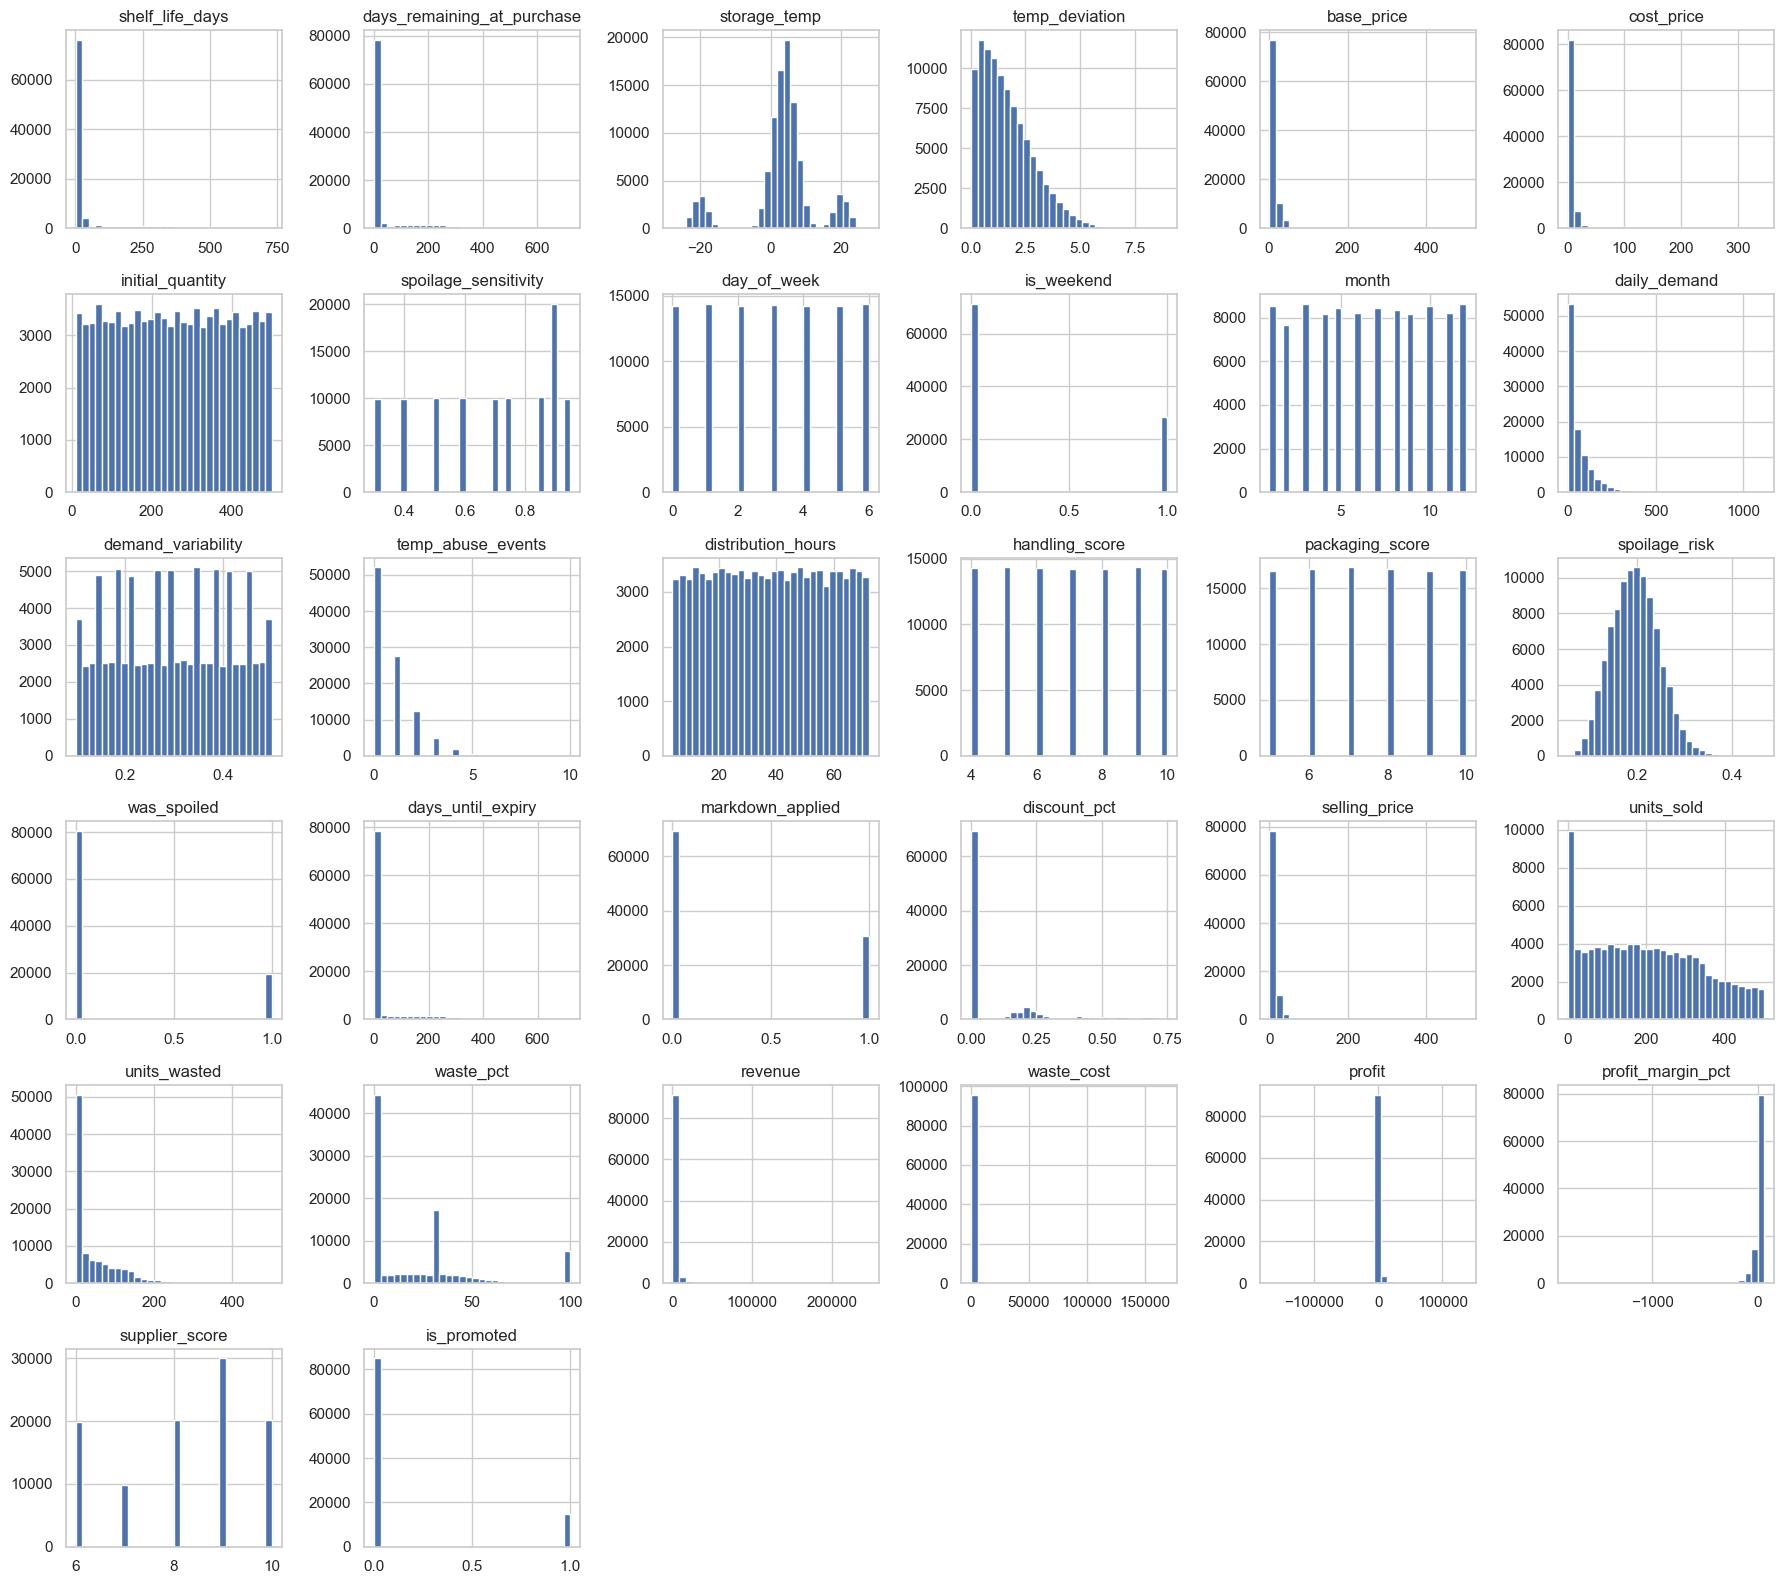

In [18]:
#the shape of each numeric column
df[num_cols].hist(bins=30, figsize=(18, 16))
plt.tight_layout()
plt.savefig(FIG_DIR / "02_numeric_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# skewness: 0 means symmetric, above 1 or below -1 means strongly skewed
df[num_cols].skew().sort_values().round(2)

profit_margin_pct            -5.34
profit                       -0.90
storage_temp                 -0.86
spoilage_sensitivity         -0.44
supplier_score               -0.37
month                        -0.01
demand_variability           -0.00
handling_score                0.00
distribution_hours            0.00
initial_quantity              0.00
day_of_week                   0.00
packaging_score               0.00
units_sold                    0.27
spoilage_risk                 0.28
markdown_applied              0.84
is_weekend                    0.95
temp_deviation                0.99
waste_pct                     1.46
was_spoiled                   1.54
temp_abuse_events             1.67
discount_pct                  1.80
is_promoted                   1.97
units_wasted                  2.40
shelf_life_days               2.71
days_remaining_at_purchase    2.79
days_until_expiry             2.79
daily_demand                  3.41
base_price                    3.64
selling_price       

In [20]:
# waste_pct and profit are the two columns I care about most
print("rows with zero waste:", round((df["waste_pct"] == 0).mean() * 100, 1), "%")
print("rows with negative profit:", round((df["profit"] < 0).mean() * 100, 1), "%")

rows with zero waste: 42.6 %
rows with negative profit: 28.7 %


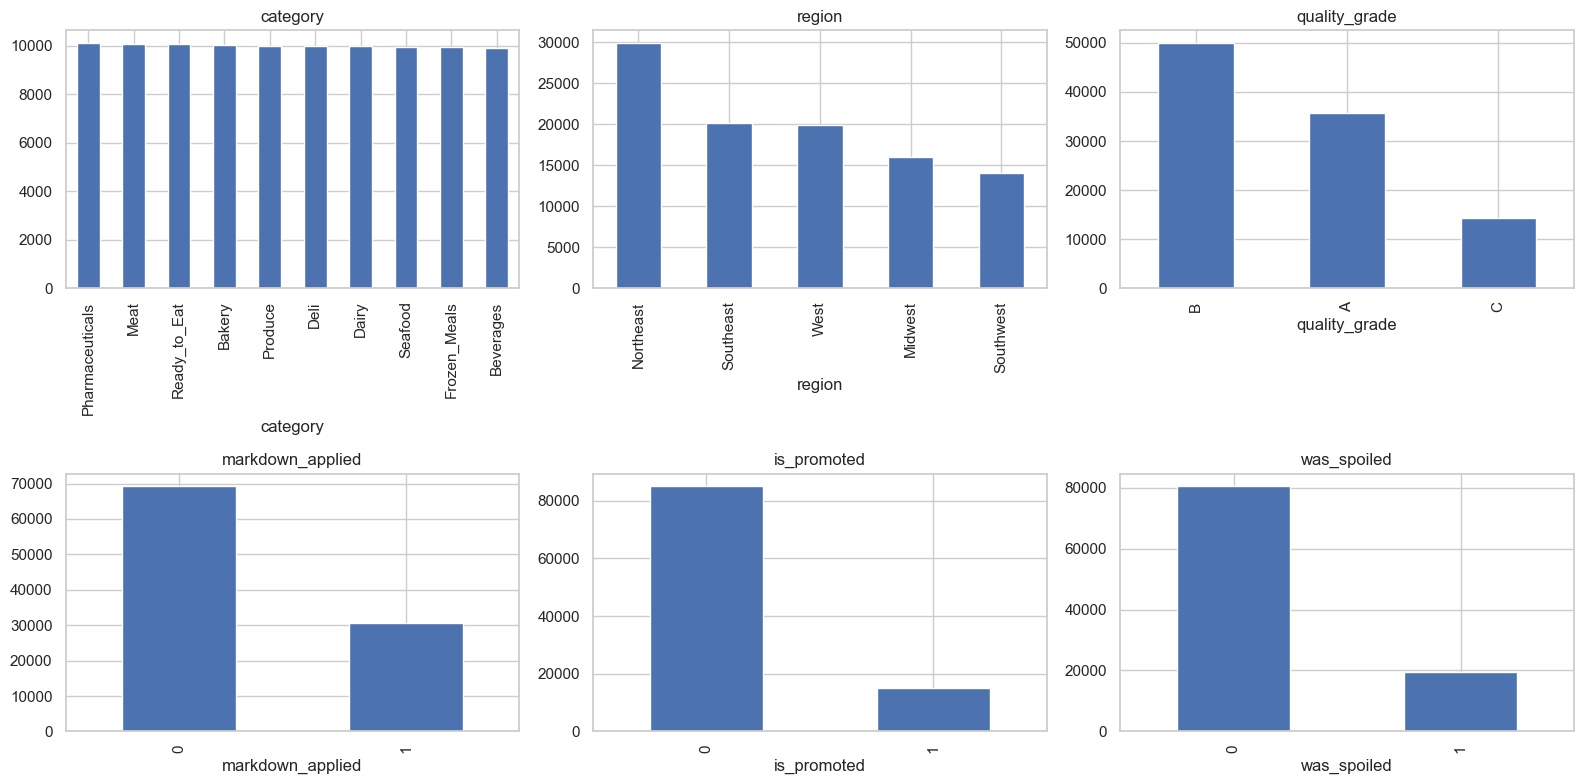

In [21]:
#for categorical columns
cols = ["category", "region", "quality_grade", "markdown_applied", "is_promoted", "was_spoiled"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cols):
    df[col].value_counts().plot(kind="bar", ax=ax, title=col)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_categorical_counts.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Outliers

I use the IQR rule: a value is an outlier if it is more than 1.5 x IQR below the first quartile or above the third quartile. Outliers are not automatically mistakes. In this project very negative profits are real batches that were a total loss, so I only count and describe them.

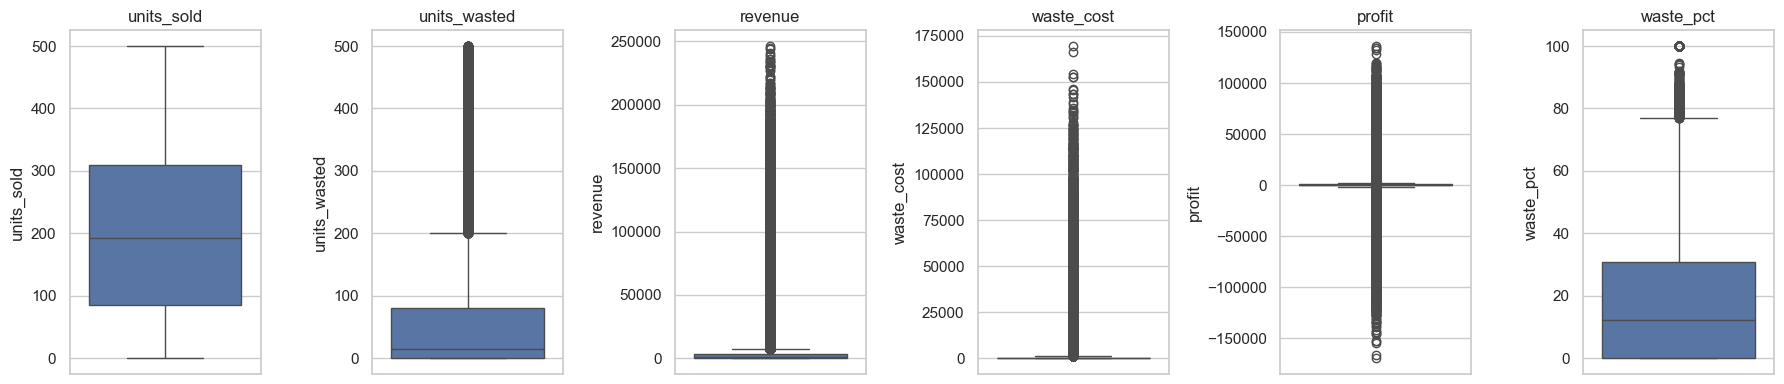

In [22]:
cols = ["units_sold", "units_wasted", "revenue", "waste_cost", "profit", "waste_pct"]

fig, axes = plt.subplots(1, len(cols), figsize=(18, 4))
for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:15s} outliers: {n:6d}  ({n / len(df) * 100:.1f}%)")

units_sold      outliers:      0  (0.0%)
units_wasted    outliers:   5184  (5.2%)
revenue         outliers:   9753  (9.8%)
waste_cost      outliers:  12082  (12.1%)
profit          outliers:  15756  (15.8%)
waste_pct       outliers:   8003  (8.0%)


In [24]:
# the worst loss-making batches: which categories are they in?
worst = df.nsmallest(100, "profit")
print("lowest profit:", df["profit"].min())
worst["category"].value_counts()

lowest profit: -169495.0


category
Pharmaceuticals    100
Name: count, dtype: int64

**Finding - outliers.**
IQR outliers: `units_wasted` 5.2 %, `revenue` 9.8 %, `waste_cost` 12.1 %, `profit` 15.8 %, `waste_pct` 8.0 %; `units_sold` none. They are kept, because they are real batches (total losses), not errors. The 100 worst batches (lowest profit -169,495) are all Pharmaceuticals.

## 5. What is linked to spoilage and waste?

This is the main part of the task. I compare the spoilage rate (the mean of `was_spoiled`, since it is 0/1) across groups.

### 5.1 By category

category
Ready_to_Eat       0.221
Meat               0.210
Pharmaceuticals    0.207
Seafood            0.207
Deli               0.194
Dairy              0.189
Produce            0.187
Bakery             0.183
Beverages          0.177
Frozen_Meals       0.169
Name: was_spoiled, dtype: float64


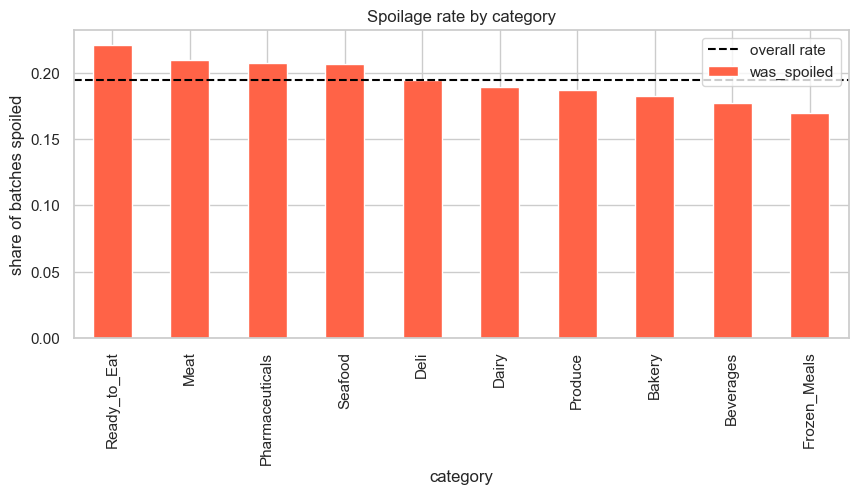

In [25]:
by_cat = df.groupby("category")["was_spoiled"].mean().sort_values(ascending=False)
print(by_cat.round(3))

by_cat.plot(kind="bar", figsize=(10, 4), color="tomato")
plt.axhline(df["was_spoiled"].mean(), color="black", linestyle="--", label="overall rate")
plt.title("Spoilage rate by category")
plt.ylabel("share of batches spoiled")
plt.legend()
plt.savefig(FIG_DIR / "05_spoilage_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

category
Ready_to_Eat       14.56
Bakery             15.35
Deli               16.90
Dairy              16.91
Seafood            17.41
Meat               18.20
Produce            18.45
Beverages          20.70
Pharmaceuticals    37.49
Frozen_Meals       50.01
Name: waste_pct, dtype: float64


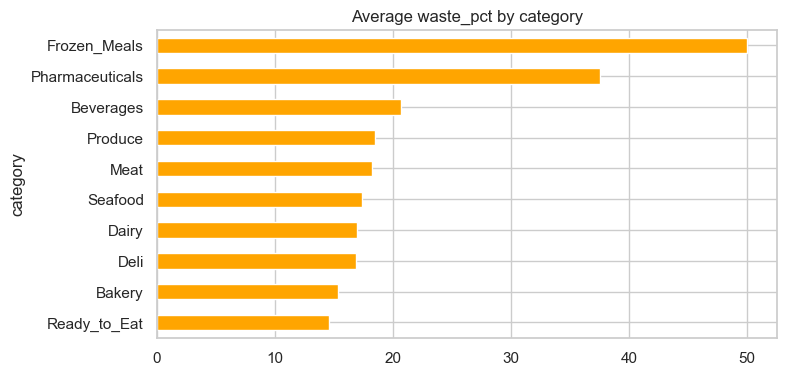

In [26]:
# same idea with the average waste_pct
waste_cat = df.groupby("category")["waste_pct"].mean().sort_values()
print(waste_cat.round(2))

waste_cat.plot(kind="barh", figsize=(8, 4), color="orange")
plt.title("Average waste_pct by category")
plt.savefig(FIG_DIR / "05_waste_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 By region, quality grade, promotion and markdown

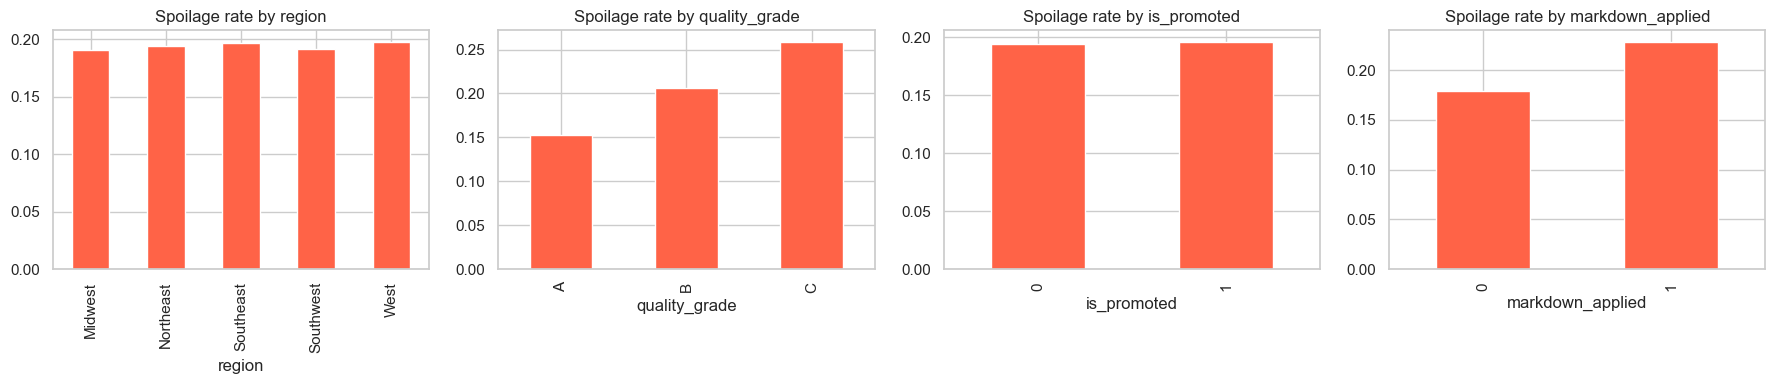

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["region", "quality_grade", "is_promoted", "markdown_applied"]):
    df.groupby(col)["was_spoiled"].mean().plot(kind="bar", ax=ax, color="tomato")
    ax.set_title("Spoilage rate by " + col)
    ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_spoilage_other_groups.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# suppliers and stores: there are many, so only look at the best and worst 5
for col in ["supplier_id", "store_id"]:
    rate = df.groupby(col)["was_spoiled"].mean().sort_values()
    print(col, "- lowest 5:")
    print(rate.head(5).round(3))
    print(col, "- highest 5:")
    print(rate.tail(5).round(3))
    print()

supplier_id - lowest 5:
supplier_id
SUPPLIER_07    0.183
SUPPLIER_14    0.185
SUPPLIER_18    0.189
SUPPLIER_09    0.190
SUPPLIER_11    0.190
Name: was_spoiled, dtype: float64
supplier_id - highest 5:
supplier_id
SUPPLIER_12    0.201
SUPPLIER_04    0.201
SUPPLIER_17    0.201
SUPPLIER_16    0.201
SUPPLIER_06    0.203
Name: was_spoiled, dtype: float64

store_id - lowest 5:
store_id
STORE_034    0.176
STORE_011    0.178
STORE_026    0.180
STORE_050    0.182
STORE_019    0.182
Name: was_spoiled, dtype: float64
store_id - highest 5:
store_id
STORE_029    0.206
STORE_021    0.209
STORE_006    0.209
STORE_017    0.211
STORE_020    0.212
Name: was_spoiled, dtype: float64



### 5.3 Two factors together (heatmaps)

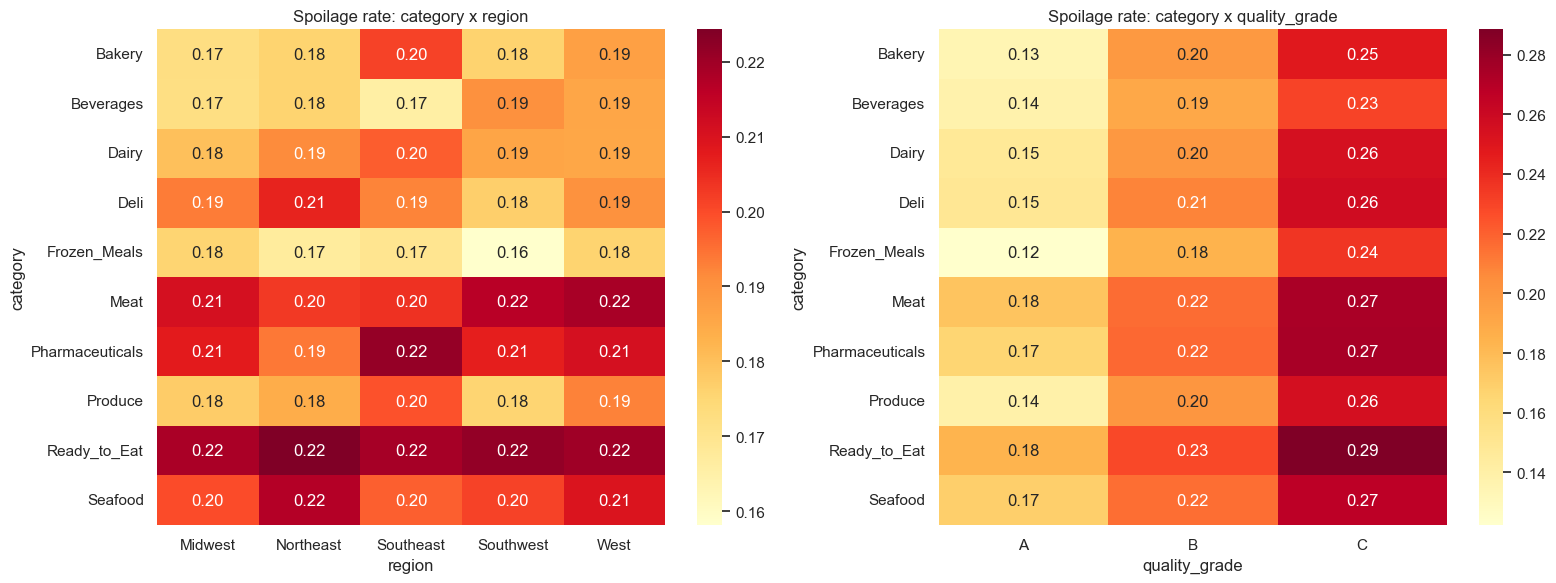

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot1 = df.pivot_table(index="category", columns="region", values="was_spoiled", aggfunc="mean")
sns.heatmap(pivot1, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Spoilage rate: category x region")

pivot2 = df.pivot_table(index="category", columns="quality_grade", values="was_spoiled", aggfunc="mean")
sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Spoilage rate: category x quality_grade")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 Numeric columns vs spoilage

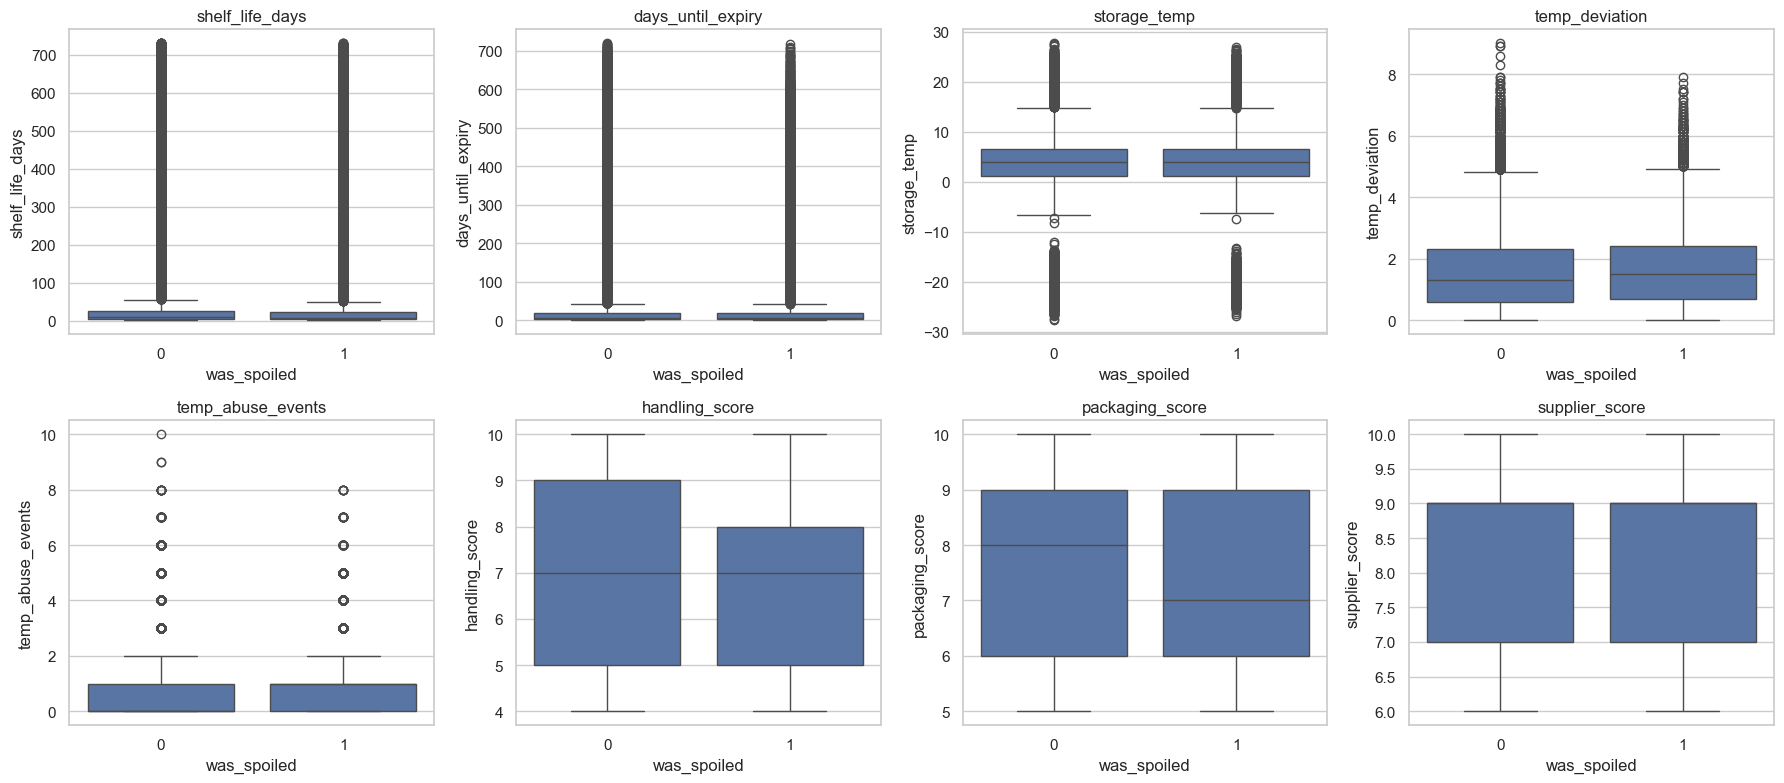

was_spoiled,0,1
shelf_life_days,67.32,66.53
days_until_expiry,54.88,53.83
storage_temp,3.09,3.29
temp_deviation,1.57,1.70
temp_abuse_events,0.79,0.86
handling_score,7.05,6.77
packaging_score,7.57,7.19
supplier_score,8.21,8.22


In [30]:
# compare spoiled and not spoiled batches on the storage / handling columns
cols = ["shelf_life_days", "days_until_expiry", "storage_temp", "temp_deviation",
        "temp_abuse_events", "handling_score", "packaging_score", "supplier_score"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=df, x="was_spoiled", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_numeric_by_spoiled.png", dpi=150, bbox_inches="tight")
plt.show()

# the same thing as numbers
df.groupby("was_spoiled")[cols].mean().T.round(2)

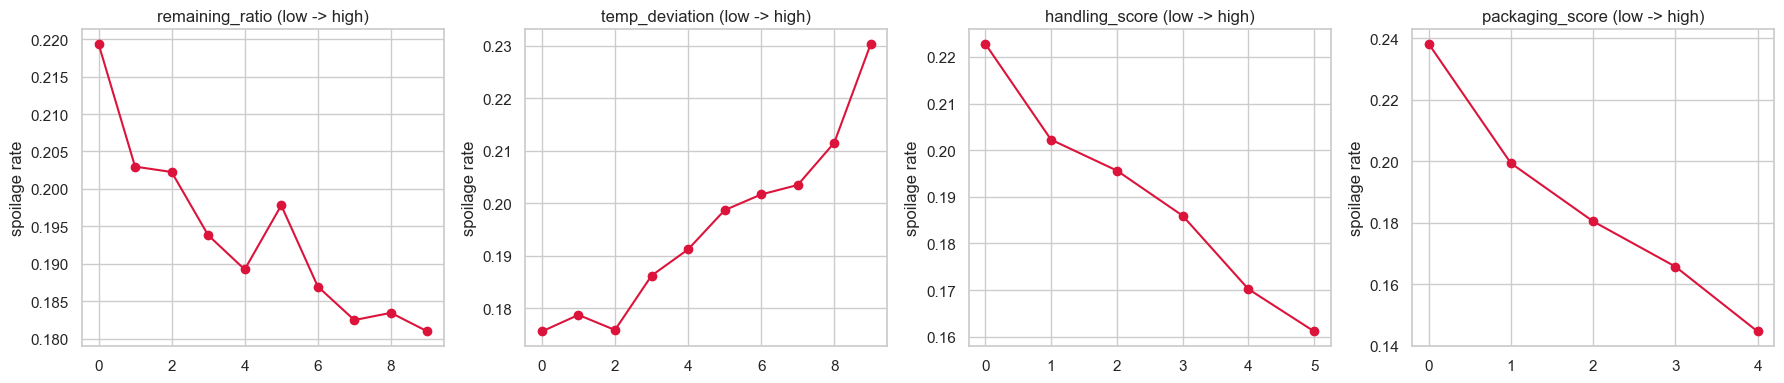

In [31]:
# spoilage rate as a column increases: cut it into 10 equal-sized groups and take the rate in each
# remaining_ratio = how much of the shelf life is left (shelf life is very different between categories)
remaining_ratio = (df["days_until_expiry"] / df["shelf_life_days"]).clip(0, 1)

to_plot = {
    "remaining_ratio": remaining_ratio,
    "temp_deviation": df["temp_deviation"],
    "handling_score": df["handling_score"],
    "packaging_score": df["packaging_score"],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, values) in zip(axes, to_plot.items()):
    groups = pd.qcut(values, 10, duplicates="drop")
    rate = df.groupby(groups, observed=True)["was_spoiled"].mean()
    ax.plot(range(len(rate)), rate.values, marker="o", color="crimson")
    ax.set_title(name + " (low -> high)")
    ax.set_ylabel("spoilage rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_spoilage_vs_numeric.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.5 Is the difference real? (chi-square test)

A chi-square test checks if a category and `was_spoiled` are linked, or if the differences could be just luck. With 100,000 rows almost every p-value will be tiny, so p-value alone is not useful here. I also compute Cramer's V, which says how *strong* the link is:

- below 0.1: very weak
- 0.1 to 0.3: weak to moderate
- above 0.3: strong

In [32]:
for col in ["category", "region", "quality_grade", "is_promoted", "markdown_applied"]:
    table = pd.crosstab(df[col], df["was_spoiled"])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    print(f"{col:18s} p-value = {p:.4g}    Cramer's V = {v:.3f}")

category           p-value = 2.139e-28    Cramer's V = 0.039
region             p-value = 0.3556    Cramer's V = 0.007
quality_grade      p-value = 3.639e-179    Cramer's V = 0.091
is_promoted        p-value = 0.5591    Cramer's V = 0.002
markdown_applied   p-value = 4.824e-74    Cramer's V = 0.058


**Finding - categorical links with spoilage.**
Overall spoilage rate is 19.4 %. By category it runs from 16.9 % (Frozen_Meals) to 22.1 % (Ready_to_Eat). Cramer's V with `was_spoiled`: `quality_grade` 0.091, `markdown_applied` 0.058, `category` 0.039, `region` 0.007, `is_promoted` 0.002; all are below 0.1 (very weak), and `region` and `is_promoted` are not significant (p = 0.36 and 0.56).
Within every category the spoilage rate rises from grade A (about 12-18 %) to B (18-23 %) to C (23-29 %), so `quality_grade` is the clearest categorical signal. Region barely changes the rate in any category (heatmap above).

## 6. Correlations

Correlation is a number between -1 and 1 that shows how two numeric columns move together. 

One thing to be careful about: `spoilage_risk` and the result columns (`units_sold`, `units_wasted`, `waste_pct`, `waste_cost`, `revenue`, `profit`, `profit_margin_pct`) are connected to `was_spoiled` because they come from the same process or happen after it. They will show high correlations, but they are not useful as inputs for a model, so I mark them and look at the rest separately.

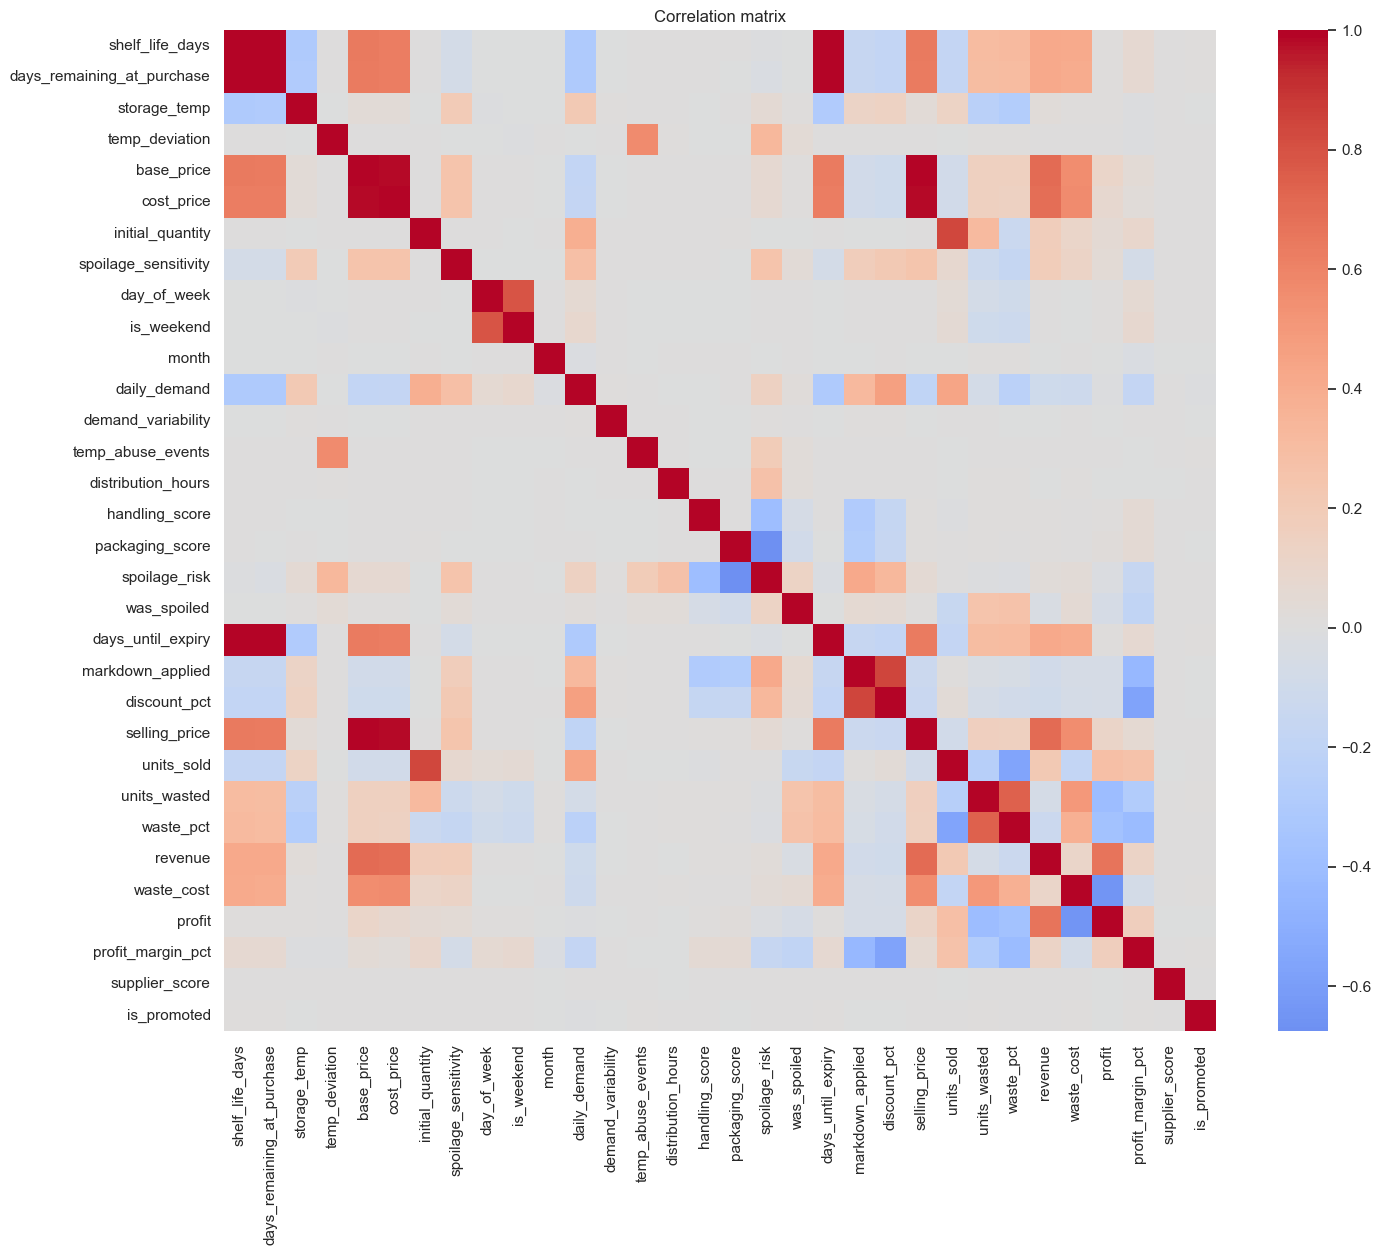

In [33]:
corr = df[num_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.savefig(FIG_DIR / "06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
outcome_cols = ["spoilage_risk", "units_sold", "units_wasted", "waste_pct",
                "waste_cost", "revenue", "profit", "profit_margin_pct"]

# correlation with was_spoiled, all columns
print("All columns:")
print(corr["was_spoiled"].drop("was_spoiled").sort_values(ascending=False).round(3).head(10))

# same thing without the outcome columns
print()
print("Without spoilage_risk and the outcome columns:")
inputs_only = corr["was_spoiled"].drop(["was_spoiled"] + outcome_cols, errors="ignore")
print(inputs_only.sort_values(ascending=False).round(3))

All columns:
waste_pct               0.264
units_wasted            0.249
spoilage_risk           0.131
markdown_applied        0.058
waste_cost              0.049
discount_pct            0.047
temp_deviation          0.043
spoilage_sensitivity    0.037
distribution_hours      0.029
temp_abuse_events       0.029
Name: was_spoiled, dtype: float64

Without spoilage_risk and the outcome columns:
markdown_applied              0.058
discount_pct                  0.047
temp_deviation                0.043
spoilage_sensitivity          0.037
distribution_hours            0.029
temp_abuse_events             0.029
daily_demand                  0.023
base_price                    0.011
cost_price                    0.011
storage_temp                  0.009
selling_price                 0.008
demand_variability            0.005
day_of_week                   0.005
is_weekend                    0.004
supplier_score                0.003
is_promoted                   0.002
month                        

In [35]:
# same for waste_pct
print(corr["waste_pct"].drop(["waste_pct"] + outcome_cols, errors="ignore").sort_values(ascending=False).round(3))

shelf_life_days               0.315
days_remaining_at_purchase    0.309
days_until_expiry             0.308
was_spoiled                   0.264
selling_price                 0.155
base_price                    0.152
cost_price                    0.149
month                         0.017
handling_score                0.016
temp_deviation                0.015
distribution_hours            0.009
temp_abuse_events             0.004
packaging_score               0.003
is_promoted                   0.003
supplier_score                0.002
demand_variability           -0.002
markdown_applied             -0.048
discount_pct                 -0.090
day_of_week                  -0.095
is_weekend                   -0.121
initial_quantity             -0.137
spoilage_sensitivity         -0.166
daily_demand                 -0.230
storage_temp                 -0.270
Name: waste_pct, dtype: float64


In [36]:
# pairs of columns that are almost the same thing (correlation above 0.85)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack()
pairs[pairs.abs() > 0.85].sort_values(ascending=False).round(3)

days_remaining_at_purchase  days_until_expiry             1.000
base_price                  selling_price                 0.996
shelf_life_days             days_remaining_at_purchase    0.992
                            days_until_expiry             0.992
base_price                  cost_price                    0.986
cost_price                  selling_price                 0.982
dtype: float64

**Finding - numeric patterns and correlations.**
Linear correlations with `was_spoiled` are small (strongest input: `packaging_score` -0.088, `markdown_applied` +0.058, `handling_score` -0.056, `discount_pct` +0.047, `temp_deviation` +0.043; `spoilage_risk` itself 0.131). The decile plots in 5.4 show the effects are small but consistent and monotone: the spoilage rate falls from about 24 % to 14 % as `packaging_score` rises, from about 22 % to 16 % as `handling_score` rises, and rises from about 18 % to 23 % as `temp_deviation` rises. The share of shelf life left (`days_until_expiry / shelf_life_days`) also shows a clear downward trend (about 22 % to 18 %), although the raw `days_until_expiry` has correlation -0.004 with spoilage, so the ratio is the right feature, not the raw days.
For `waste_pct` the strongest links are `shelf_life_days` (+0.31), `storage_temp` (-0.27) and `daily_demand` (-0.23). Frozen_Meals has the highest average `waste_pct` (50.0 %) and Pharmaceuticals the second highest (37.5 %), against 14.6-20.7 % for the other categories, although Frozen_Meals has the lowest spoilage rate, so waste is not the same thing as spoilage.
Almost duplicate columns (|r| > 0.85): `days_remaining_at_purchase` / `days_until_expiry` (1.000), `base_price` / `selling_price` (0.996), `shelf_life_days` with both day columns (0.992), `base_price` / `cost_price` (0.986), `cost_price` / `selling_price` (0.982).

## 7. Patterns over time

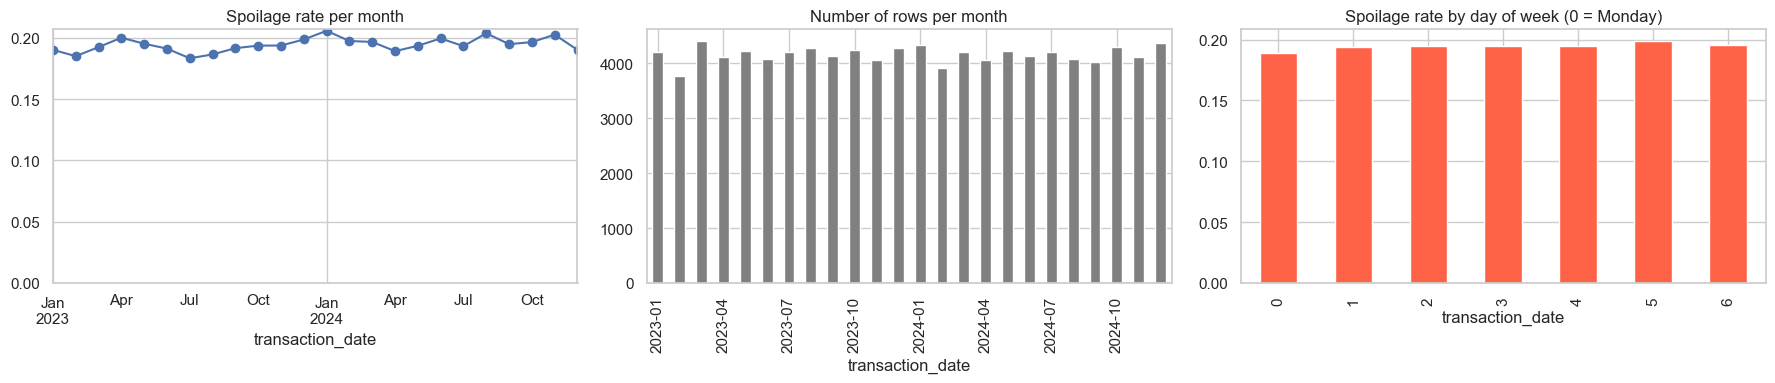

In [37]:
month = df["transaction_date"].dt.to_period("M")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df.groupby(month)["was_spoiled"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Spoilage rate per month")
axes[0].set_ylim(0, None)

df.groupby(month).size().plot(kind="bar", ax=axes[1], color="grey")
axes[1].set_title("Number of rows per month")
axes[1].set_xticks(axes[1].get_xticks()[::3])

df.groupby(df["transaction_date"].dt.dayofweek)["was_spoiled"].mean().plot(kind="bar", ax=axes[2], color="tomato")
axes[2].set_title("Spoilage rate by day of week (0 = Monday)")

plt.tight_layout()
plt.savefig(FIG_DIR / "07_time_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding - time.**
The spoilage rate stays between about 18 % and 20 % in every month from 2023-01 to 2024-12 and is flat across weekdays (about 19-20 %). The number of rows per month is steady (about 3,800 to 4,400). There is no visible trend or seasonality.

## 8. Interactive charts

In [38]:

import plotly.express as px

rate = df.groupby("category")["was_spoiled"].mean().reset_index()
fig = px.bar(rate.sort_values("was_spoiled"), x="was_spoiled", y="category", orientation="h",
             title="Spoilage rate by category")
fig.write_html(FIGURES_INTERACTIVE_DIR / "interactive_spoilage_by_category.html")
fig.show()

In [39]:
monthly = (df.assign(month=df["transaction_date"].dt.to_period("M").dt.to_timestamp())
             .groupby(["month", "category"])["was_spoiled"].mean().reset_index())

fig = px.line(monthly, x="month", y="was_spoiled", color="category",
              title="Monthly spoilage rate by category (click a name in the legend to hide it)")
fig.write_html(FIGURES_INTERACTIVE_DIR / "interactive_monthly_by_category.html")
fig.show()

In [40]:
fig = px.histogram(df, x="profit", color="category", nbins=80, marginal="box",
                   title="Profit distribution by category")
fig.write_html(FIGURES_INTERACTIVE_DIR / "interactive_profit_distribution.html")
fig.show()

## 9. Key findings

**Data quality**
- 100,000 rows x 42 columns, 10 categories, 50 stores, 5 regions, 20 suppliers, 2023-01-01 to 2024-12-31.
- No missing values, no duplicate rows (ignoring `record_id`), and no impossible values (Section 2 checks pass).
- `discount_pct` is stored as a fraction (0 to 0.75), `waste_pct` as a percent (0 to 100).
- `days_remaining_at_purchase` is the date gap; `days_until_expiry` is 0-3 days lower, and this gap is not explained by `distribution_hours` (origin unknown, a data limitation).

**Target and outcomes**
- 19.4 % of batches spoiled (19,442 of 100,000): moderate imbalance, so use PR-AUC/recall and class weights, not accuracy.
- 42.6 % of batches have zero waste; 28.7 % have negative profit. Outliers are kept as real batches.

**What is linked to spoilage (all effects are small to moderate)**
- `quality_grade` (A < B < C in every category), `packaging_score`, `handling_score`, `temp_deviation` and the share of shelf life left show consistent monotone effects.
- `region`, `is_promoted`, month and weekday show no meaningful effect; `category` is weak (V = 0.039).
- Expect modest predictive power from Track 3A and report that as a limitation.

**What is linked to waste**
- Waste follows shelf life, storage temperature and demand, and is highest for Frozen_Meals and Pharmaceuticals, which are not the highest-spoilage categories.

**Notes for modelling**
- Do not use `spoilage_risk` or the outcome columns as inputs (see the leakage rule from M1-T01).
- Check `quality_grade` for leakage before using it as an input: it is the strongest categorical signal and may be assigned after the outcome (M1-T06).
- `markdown_applied` / `discount_pct` correlate positively with spoilage (+0.058 / +0.047). Marked-down batches spoil more, which is consistent with discounts being given to batches that already look risky, not with discounts causing spoilage. This is a hypothesis for the Track 3B confounding check, not a result.
- Use ratios (`days_until_expiry / shelf_life_days`) and drop one of each near-duplicate pair (days, prices).
- No visible drift over time.
